In [690]:
import numpy as np
import pandas as pd
import geopandas as gpd
from geopy.distance import geodesic
from path_config import PathConfig
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import math
paths = PathConfig()

In [ ]:
buildings = gpd.read_file(paths.build_path)
vegetation = gpd.read_file(paths.vege_path)
water = gpd.read_file(paths.waters_path)
roads = gpd.read_file(paths.roads_path)
border = gpd.read_file(paths.border_path)
kabinets = pd.read_csv((paths._processed_saha_olcum_dir / "Kabinets.csv"))
kabinets = kabinets.loc[:, ~kabinets.columns.str.contains('^Unnamed')]

layers = [buildings, vegetation, water, roads, border]
for layer in layers:
    if layer.crs != "EPSG:32635":
        layer = layer.to_crs(epsg=32635)

utm_crs = "EPSG:32635"

buildings, vegetation, water, roads, border = layers

stations_gdf = gpd.GeoDataFrame(
    kabinets,
    geometry=gpd.points_from_xy(np.array(kabinets["Longitude"]), np.array(kabinets["Latitude"])),
    crs="EPSG:4326"
).to_crs(utm_crs)

grid_spacing = 5
border = border.to_crs(utm_crs)
minx, miny, maxx, maxy = border.total_bounds
x_coords = np.arange(minx, maxx, grid_spacing)
y_coords = np.arange(miny, maxy, grid_spacing)

grid_points = [Point(x, y) for x in x_coords for y in y_coords]
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs=utm_crs).to_crs(utm_crs)

border_polygon = Polygon(border.geometry.iloc[0])
grid_gdf = grid_gdf[grid_gdf.geometry.within(border_polygon)]

In [692]:
dl_data = pd.read_excel(paths.dl_path, sheet_name='Series Formatted Data')
ul_data = pd.read_excel(paths.ul_path, sheet_name='Series Formatted Data')

dl_data = dl_data.drop(["Message","Technology_Mode"],axis=1)
dl_data = dl_data.loc[:, ~dl_data.columns.str.contains('^Unnamed')]

ul_data = ul_data.drop(["Message","Technology_Mode"],axis=1)
ul_data = ul_data.loc[:, ~ul_data.columns.str.contains('^Unnamed')]

dl_data_group_by_location = pd.read_csv(paths._processed_saha_olcum_dir / "dl_data_group_by_location.csv")

In [693]:
dl_data_group_by_location = dl_data_group_by_location[[
                    "x",
                    "y",
                    "Longitude",
                    "Latitude",
                    "NR_UE_RSRP_0",
                    "NR_UE_Nbr_RSRP_0",
                    "NR_UE_Nbr_RSRP_1",
                    "NR_UE_Nbr_RSRP_2",
                    "NR_UE_Nbr_RSRP_3",
                    "NR_UE_Nbr_RSRP_4",
                    "NR_UE_PCI_0",
                    "NR_UE_Nbr_PCI_0",
                    "NR_UE_Nbr_PCI_1",
                    "NR_UE_Nbr_PCI_2",
                    "NR_UE_Nbr_PCI_3",
                    "NR_UE_Nbr_PCI_4"
                    ]]

pci_cols = [col for col in dl_data_group_by_location.columns if "PCI" in col]
rsrp_cols = [col for col in dl_data_group_by_location.columns if "RSRP" in col]

dl_data_group_by_location = dl_data_group_by_location.dropna(how="all", subset=pci_cols)

In [694]:
grid_locations = np.column_stack((grid_gdf.geometry.x, grid_gdf.geometry.y))

In [695]:
def calculate_bearing(lat1, lon1, lat2, lon2):
    
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    
    dlon = lon2_rad - lon1_rad
    
    y = math.sin(dlon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(dlon)
    
    bearing_rad = math.atan2(y, x)
    
    bearing_deg = (math.degrees(bearing_rad) + 360) % 360
    
    return bearing_deg

In [696]:
def latitude_to_meter(data, col=None):
    if col:
        latitude = data[col]*111320
    else:
        latitude = data*111320
    return latitude

def longitude_to_meter(data, cols=None):
    # cols[0] Latitude, cols[1] Longitude
    if cols:
        longitude = np.cos(np.radians(data[cols[0]]))*111320*(data[cols[1]])
    else:
        longitude = np.cos(np.radians(data[0]))*111320*(data[1])
    return longitude

In [697]:
def create_signal_data(signal_column, pci_column, data, col_names, fill_na_value=-200):
    col_names = np.append(col_names, ['Longitude','Latitude'])
    
    signal_data_list = []
    for idx, row in data[pci_column].iterrows():
        temp_dict = {}
        for t,i in enumerate(row):
            if not np.isnan(i):
                temp_dict[str(int(i))] = data[signal_column[t]][idx]
                temp_dict['Longitude'], temp_dict['Latitude'] = data['Longitude'][idx], data['Latitude'][idx]
        signal_data_list.append(temp_dict)
    signal_data = pd.DataFrame(signal_data_list)[col_names].fillna(fill_na_value)

    lon, lat = longitude_to_meter(signal_data, cols=["Latitude","Longitude"]), latitude_to_meter(signal_data, col=["Latitude"])
    signal_data["Latitude"], signal_data["Longitude"] = lat, lon
    
    return signal_data

signal_data = create_signal_data(
    signal_column = rsrp_cols, 
    pci_column = pci_cols, 
    data = dl_data_group_by_location, 
    col_names = stations_gdf["PCI"].values
    )

signal_data

,30,40,59,48,68,76,3,13,23,Longitude,Latitude
0,-200.00,-125.15,-200.0,-200.0,-124.30,-124.5,-200.0,-200.0,-200.0,2.433790e+06,4.575884e+06
1,-123.30,-123.05,-200.0,-200.0,-125.00,-123.8,-200.0,-200.0,-200.0,2.433788e+06,4.575891e+06
2,-124.15,-122.50,-200.0,-200.0,-125.35,-125.4,-200.0,-124.9,-200.0,2.433786e+06,4.575897e+06
3,-200.00,-124.75,-200.0,-200.0,-123.65,-121.2,-200.0,-200.0,-200.0,2.433784e+06,4.575901e+06
4,-200.00,-124.85,-200.0,-200.0,-122.60,-121.5,-200.0,-200.0,-200.0,2.433784e+06,4.575903e+06
...,...,...,...,...,...,...,...,...,...,...,...
1120,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435251e+06,4.575211e+06
1121,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435272e+06,4.575211e+06
1122,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435305e+06,4.575222e+06
1123,-200.00,-200.00,-200.0,-200.0,-200.00,-200.0,-200.0,-200.0,-200.0,2.435312e+06,4.575223e+06


In [698]:
def create_features(stations, data):
    locations = np.array(data[["Latitude","Longitude"]])
    bs_locations = np.column_stack((stations.Latitude,stations.Longitude))
    bs_data = stations[['Azimuth','Vertical_Beamwidth','Height']]

    # j baz istasyonunu, i lokasyonu temsil ediyor
    def create_features_j(bs_loc,locations):
        
        features_j = []
        for loc in locations: 
            distance = geodesic(loc, bs_loc).meters
            features_ij= [
                latitude_to_meter(loc[0]),                    
                longitude_to_meter(loc),                  
                latitude_to_meter(bs_loc[0]),                            
                longitude_to_meter(bs_loc),                 
                distance,
                np.log(max(distance, 1)),
                calculate_bearing(loc[0], loc[1], bs_loc[0], bs_loc[1]),
                float(bs_data["Azimuth"].iloc[0]),
                float(bs_data["Vertical_Beamwidth"].iloc[0]),
                float(bs_data["Height"].iloc[0])
                # eklenebilecek özellikler:
                # su var ya da yok, bina varsa kat yüksekliği, yeşillik var ya da yok gibi.
                ]
            features_j.append(features_ij)

        return np.array(features_j)
    
    return np.stack([create_features_j(bs_loc,locations) for bs_loc in bs_locations])

features = create_features(stations_gdf, dl_data_group_by_location)
print(features.shape)

grid_data = np.column_stack((grid_gdf.to_crs("EPSG:4326").geometry.y, grid_gdf.to_crs("EPSG:4326").geometry.x))
grid_data = pd.DataFrame(grid_data, columns=["Latitude", "Longitude"])
grid_data

pred_features = create_features(stations_gdf, grid_data)

print(pred_features.shape)

(9, 1125, 10)
(9, 68463, 10)


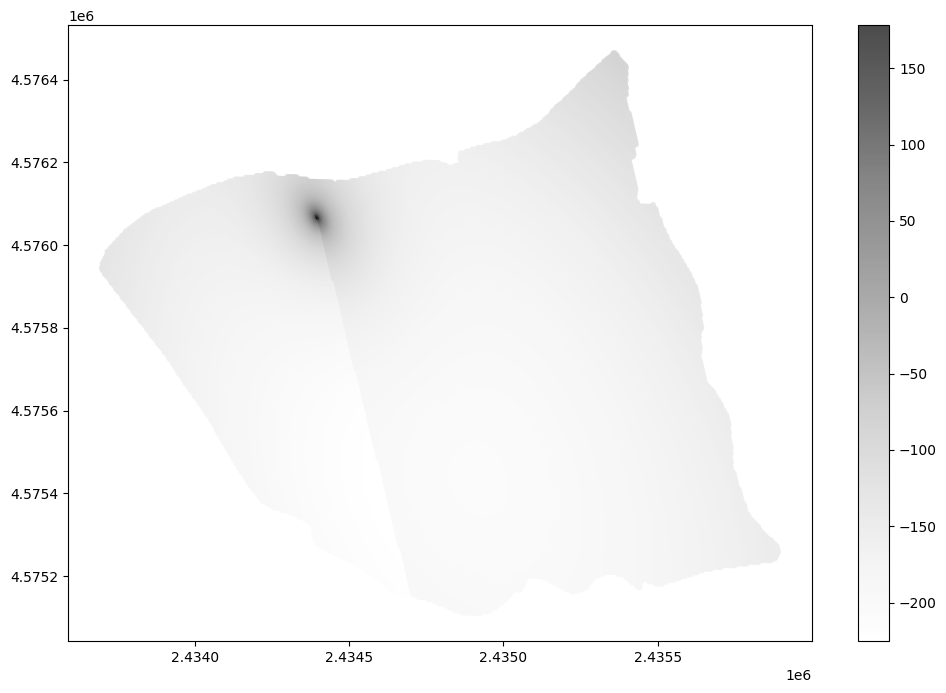

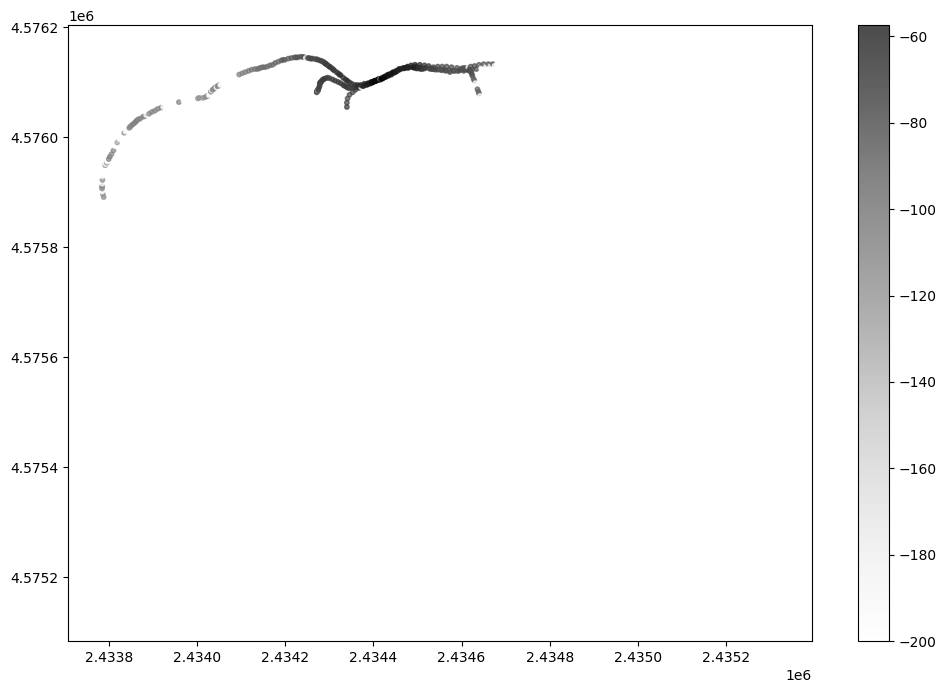

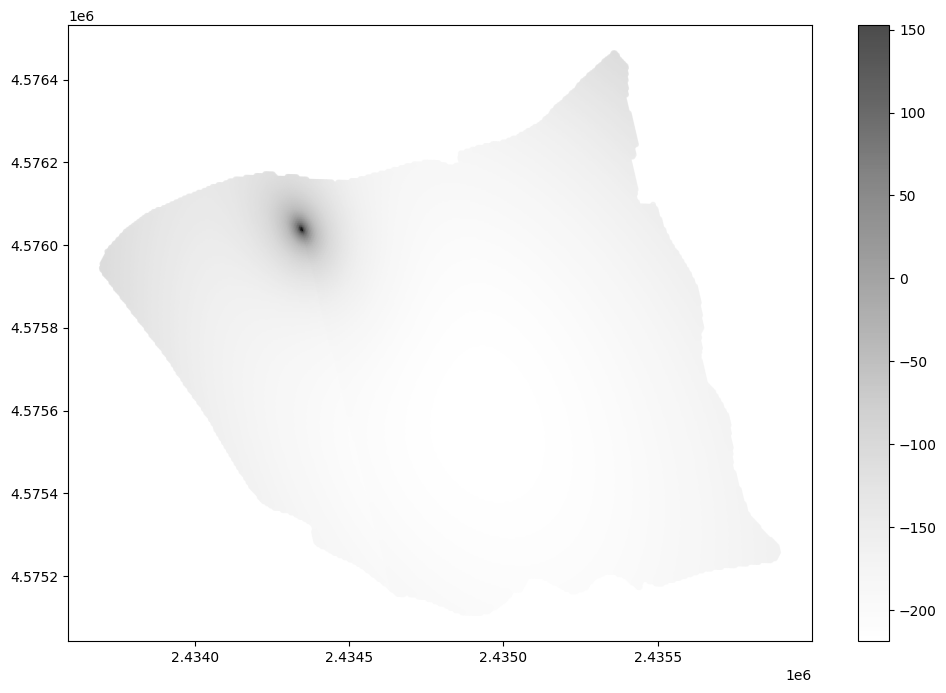

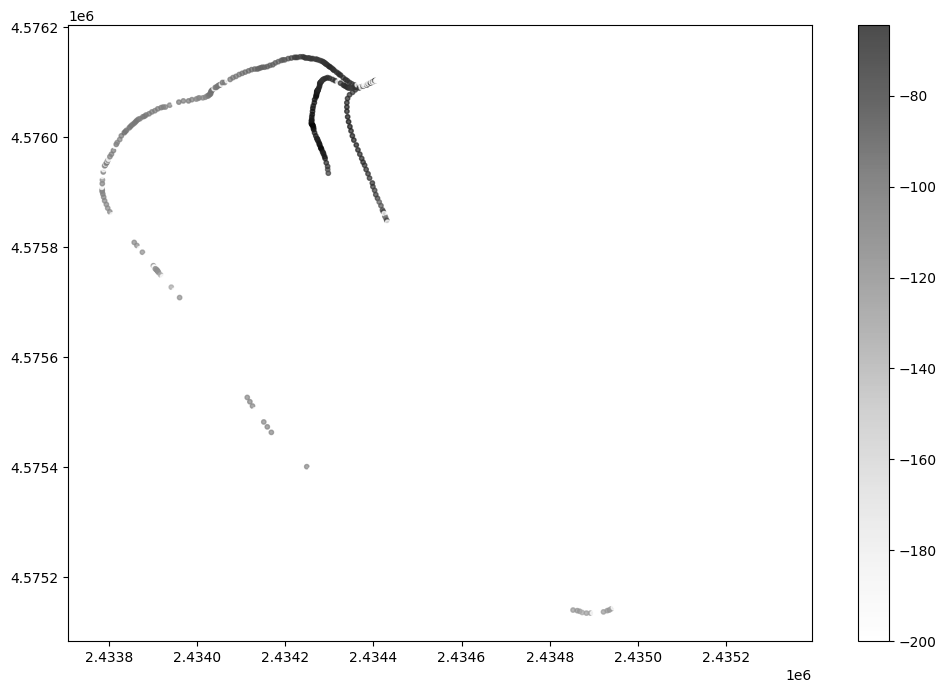

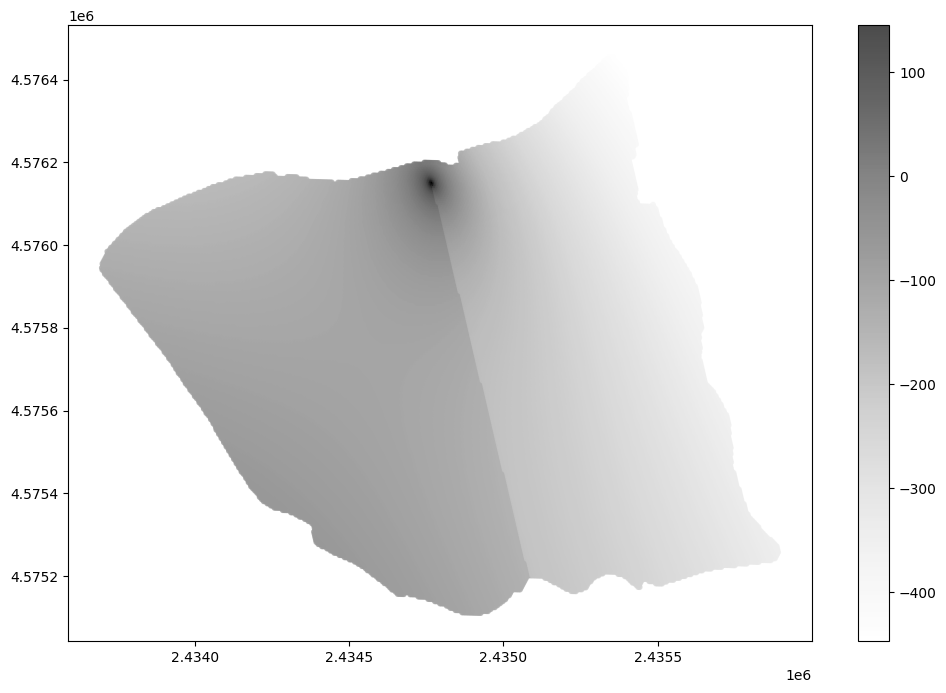

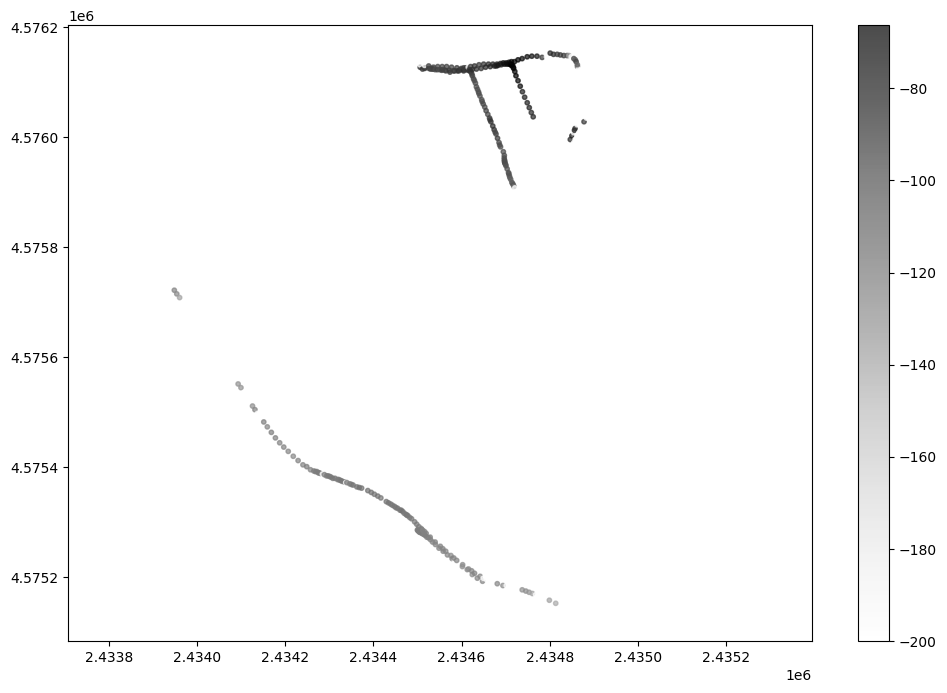

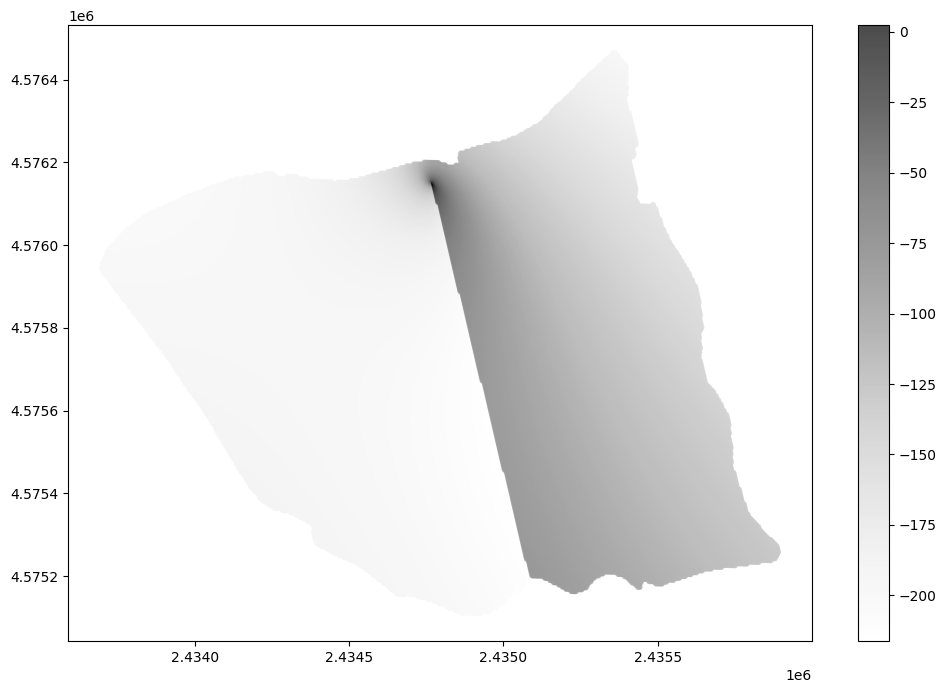

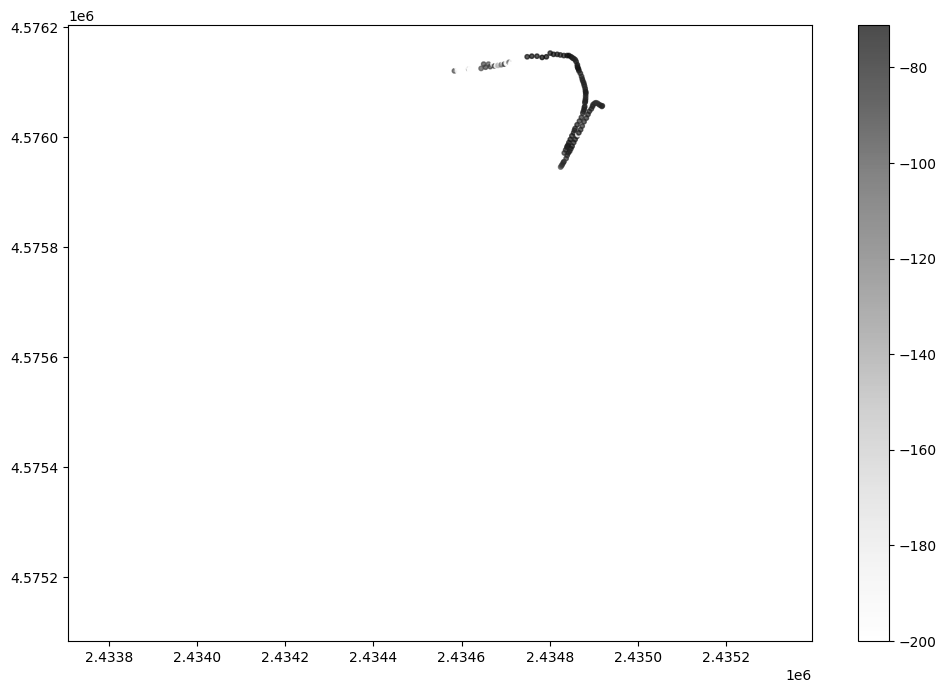

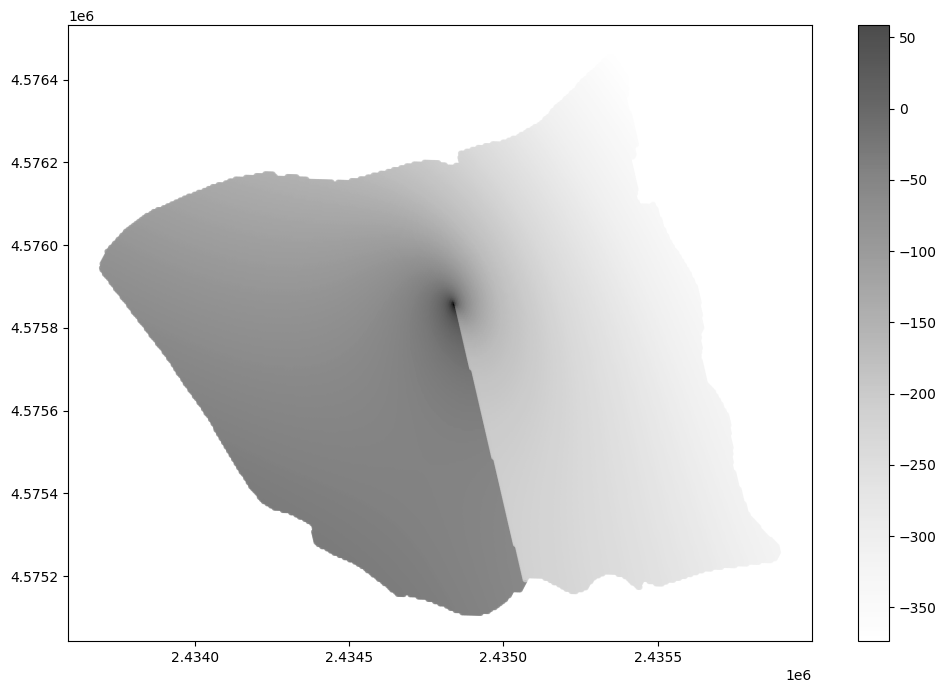

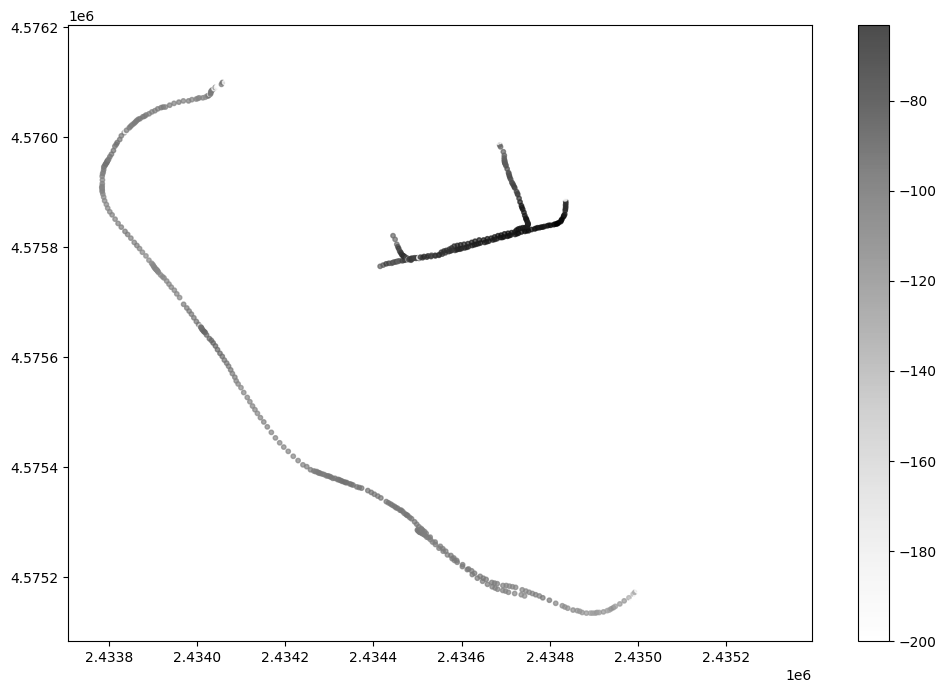

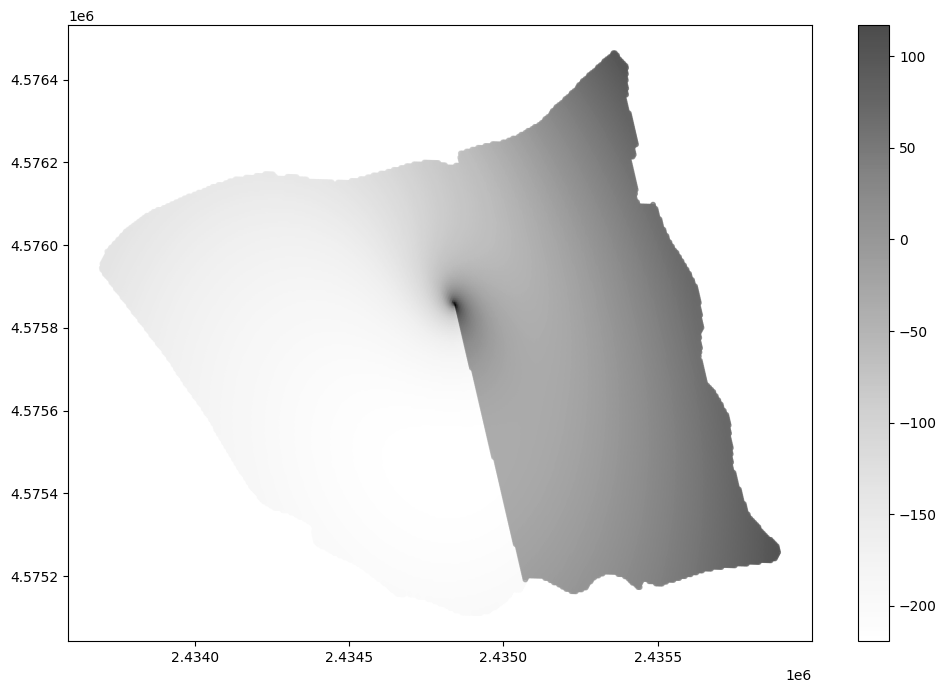

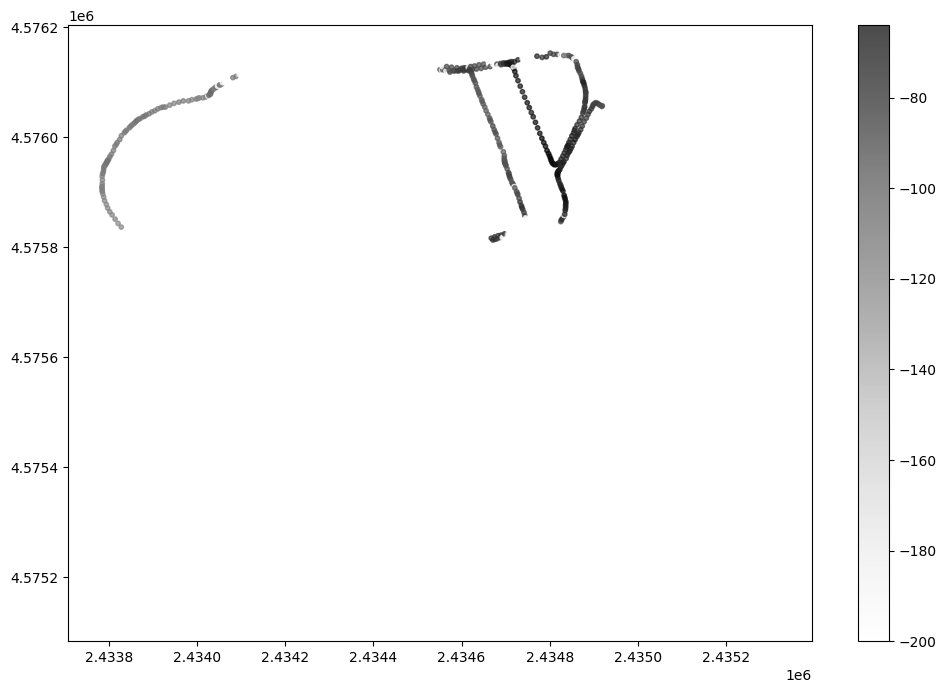

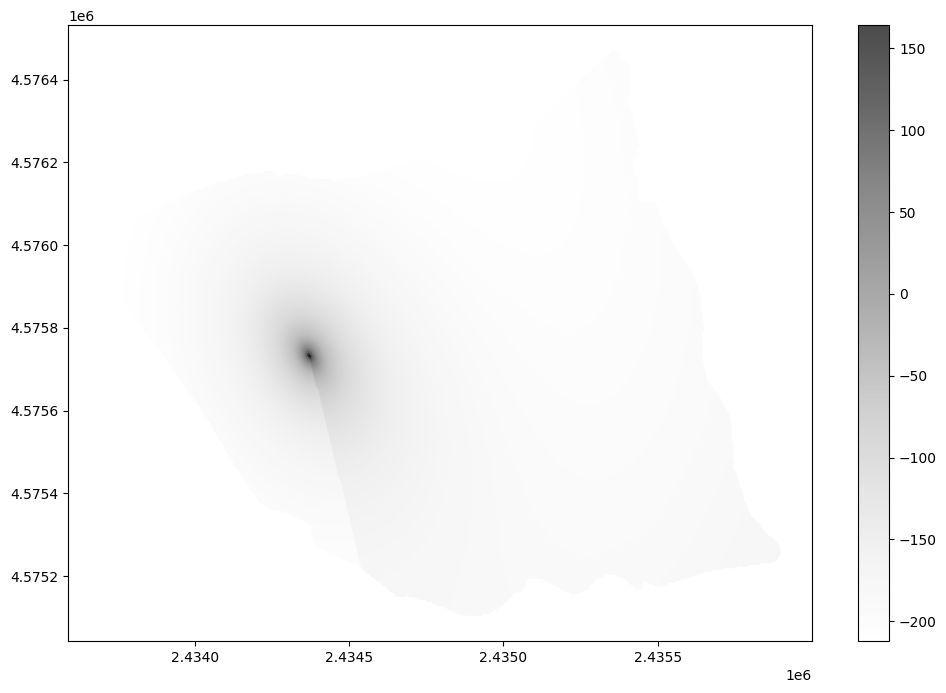

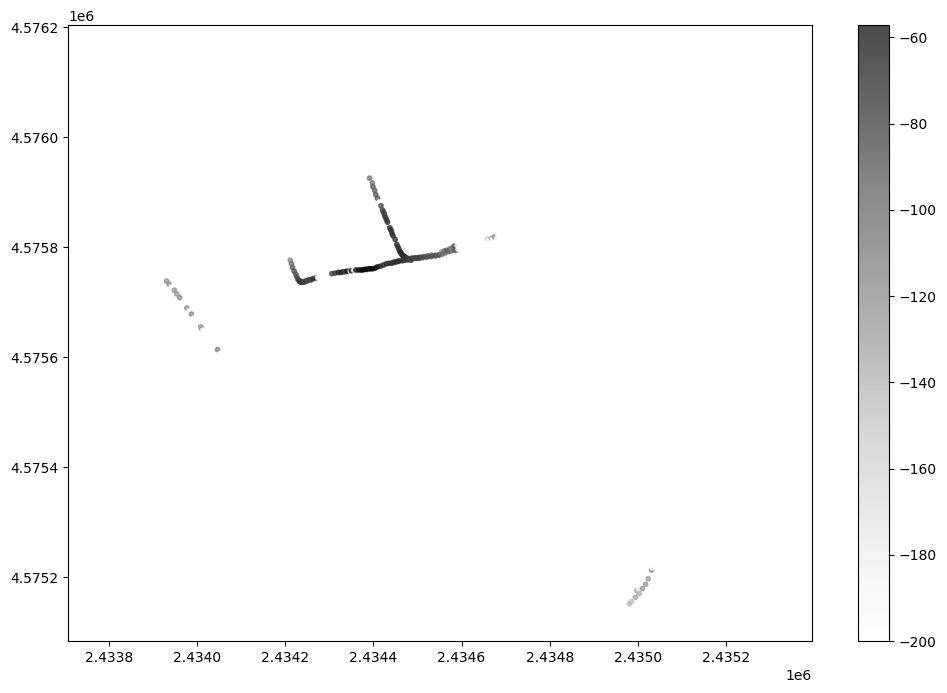

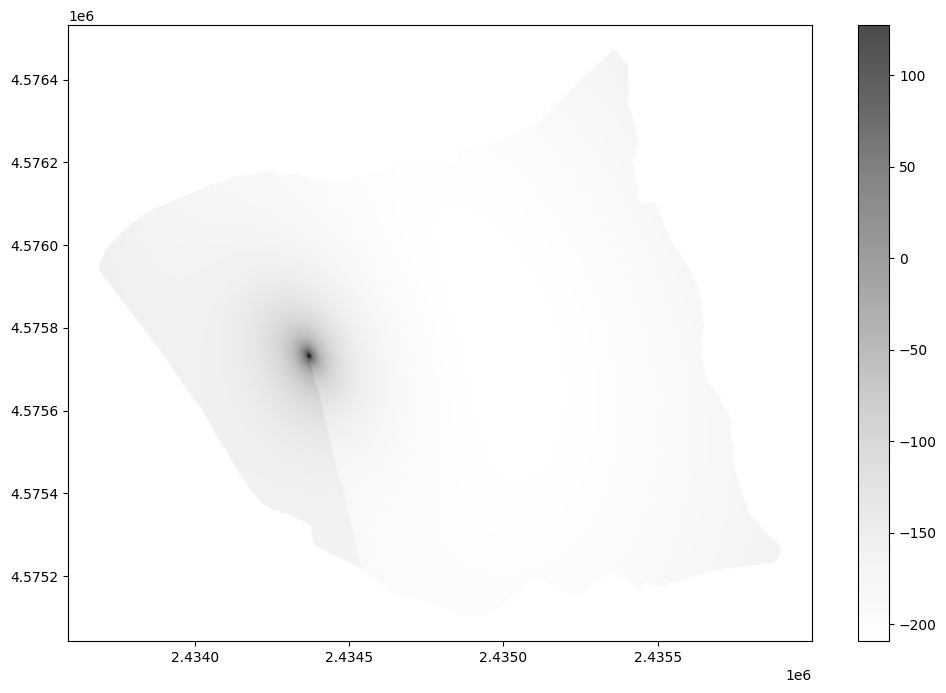

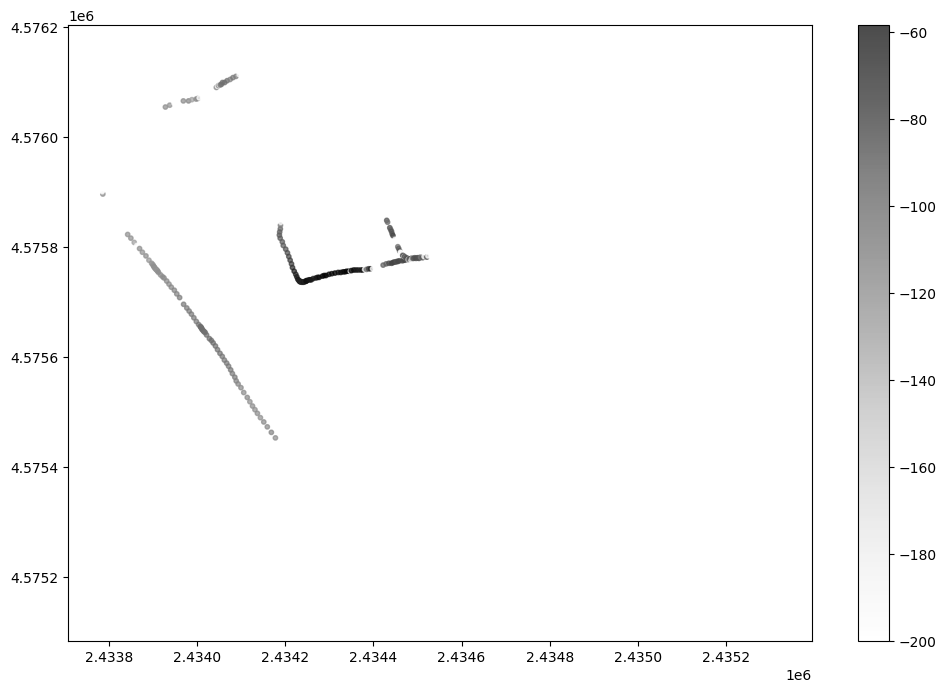

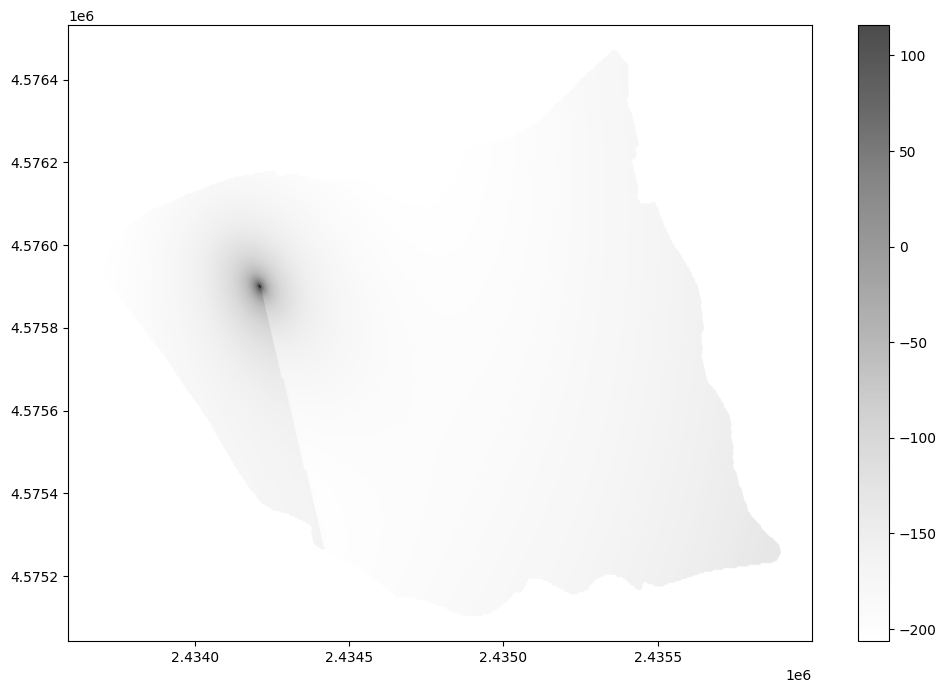

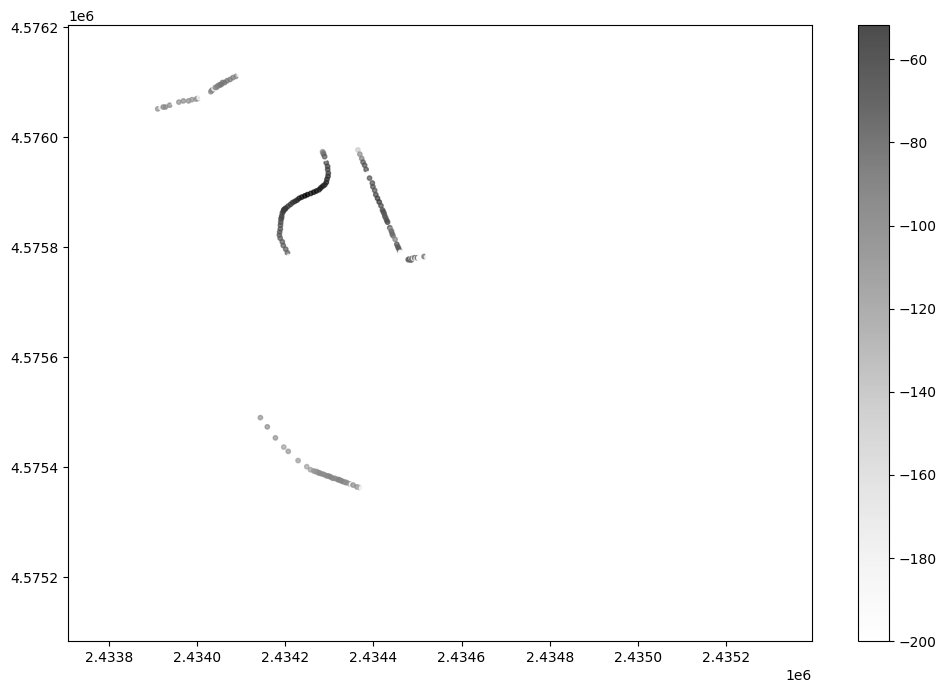

In [700]:
from sklearn.linear_model import LinearRegression

for i in range(9):
    X_train = features[i]
    X_test = pred_features[i]
    y_train = signal_data.iloc[:,i]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    sc = ax.scatter(
        pd.DataFrame(X_test)[1],
        pd.DataFrame(X_test)[0],
        c=y_pred,
        cmap="Greys",
        s=10,
        alpha=0.7
    )

    cbar = plt.colorbar(sc)

    plt.show()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)
    sc = ax.scatter(
    pd.DataFrame(X_train)[1],
    pd.DataFrame(X_train)[0],
    c=y_train,
    cmap="Greys",
    s=10,
    alpha=0.7
    )

    cbar = plt.colorbar(sc)
